# Proyecto Integrador CI/CD con Docker y GitHub Actions

## Integrantes Grupo #3
- Brenda Nicole Henriquez Amaya 
- Jonathan Vladimir Montes Rodriquez
- Beatriz Eunice Beltrán López

**Fecha de entrega:** lunes 29/06/2026

## Introducción

Durante este proyecto se integraron los conocimientos adquiridos sobre Docker, contenerización de aplicaciones, Integración Continua (CI) y Entrega Continua (CD) mediante GitHub Actions. Se desarrolló una API sencilla en Python utilizando Flask, la cual fue validada mediante pruebas automatizadas, empaquetada en una imagen Docker y preparada para un flujo de despliegue automatizado.

## Objetivo del Proyecto

Desarrollar un pipeline CI/CD que permita:

- Ejecutar pruebas automatizadas.
- Construir una imagen Docker.
- Versionar la aplicación mediante Git.
- Publicar la imagen en un registro.
- Automatizar el proceso de integración y despliegue.

## Arquitectura General

```text
GitHub
 │
 ▼
GitHub Actions
 │
 ▼
Pruebas
 │
 ▼
Docker Build
 │
 ▼
Docker Registry
 │
 ▼
Deploy

```

## Escenario del Proyecto

Se simuló el flujo de trabajo de una empresa que desarrolla una API en Python para consultar información de ventas. Cada vez que se realiza un cambio en el código fuente, el pipeline ejecuta automáticamente las pruebas, construye la imagen Docker y prepara la aplicación para su despliegue.

## Estructura del Proyecto
```text
ventas_api/
│
├── app.py
├── requirements.txt
├── tests/
│   └── test_app.py
├── Dockerfile
└── .github/
    └── workflows/
        └── pipeline.yml
```

## Desarrollo de la Aplicación

Como primer paso se desarrolló una API sencilla utilizando Flask. Se creó el archivo app.py, el cual implementa un endpoint principal que devuelve un mensaje en formato JSON indicando que la API se encuentra operativa.

También se creó el archivo requirements.txt, donde se definieron las dependencias necesarias para ejecutar la aplicación y las pruebas automatizadas.

**Evidencia**

Creación de los archivos app.py, requirements.txt y la carpeta tests.

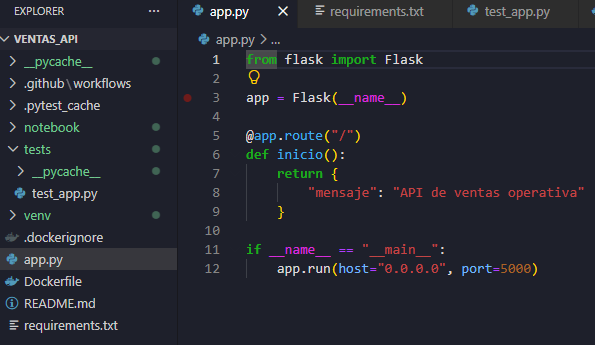

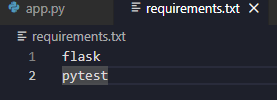

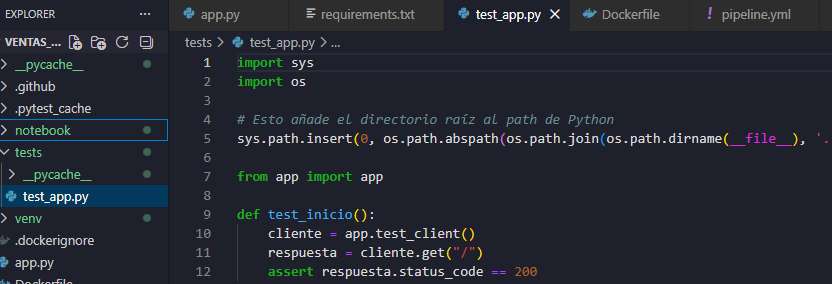

## Pruebas Automatizadas

Para verificar el correcto funcionamiento de la API se implementó una prueba unitaria utilizando pytest. Esta prueba valida que el endpoint principal responda correctamente con un código de estado HTTP 200 (OK).

Antes de continuar con el proyecto se ejecutaron las pruebas localmente para confirmar que la aplicación funcionaba correctamente.

**Evidencia:**

- Ejecución la prueba automatizada:
- Valida la sintaxis (como buena práctica adicional):

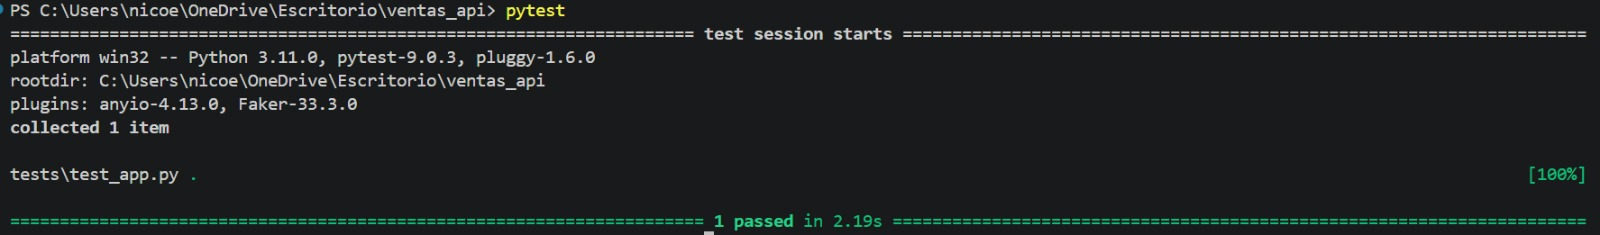

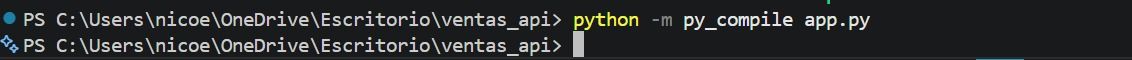


## Verificación Local

Después de validar las pruebas, la aplicación se ejecutó localmente para comprobar su funcionamiento desde el navegador mediante la dirección:

http://localhost:5000

La respuesta obtenida fue un objeto JSON indicando que la API de ventas se encuentra operativa.

**Evidencia**
- Navegador mostrando la respuesta JSON de la API.

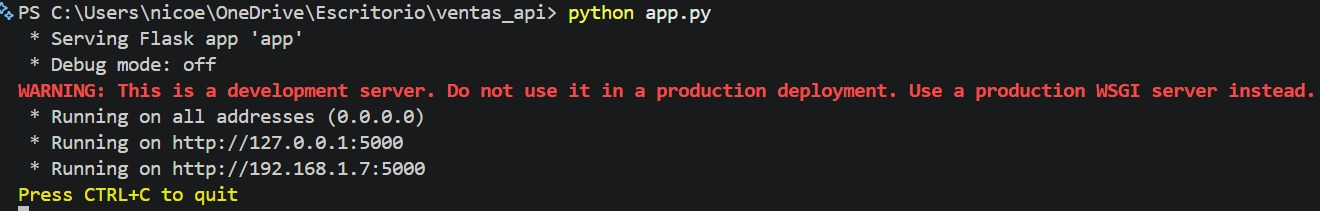

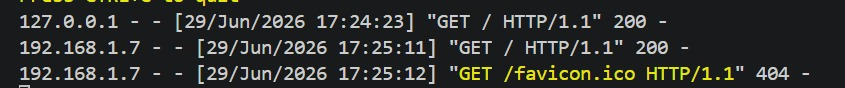

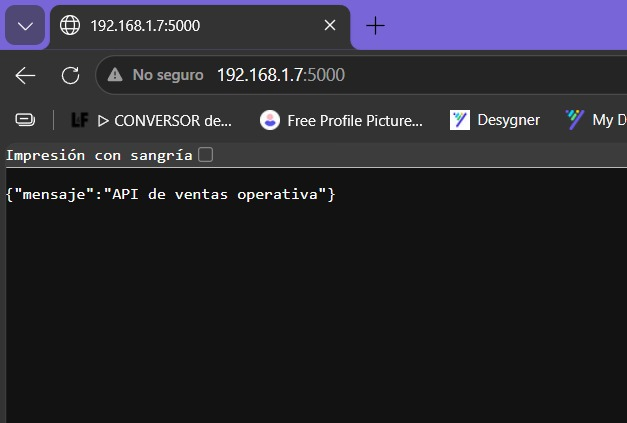

## Resultados

Durante esta etapa se obtuvo una aplicación funcional desarrollada en Flask, con sus dependencias correctamente definidas y validada mediante pruebas automatizadas. Además, se verificó el correcto funcionamiento de la API en un entorno local y el código quedó preparado para ser utilizado en las siguientes fases del proyecto, correspondientes a la creación de la imagen Docker y la implementación del pipeline CI/CD.

---

# Contenerización de la Aplicación con Docker

Una vez desarrollada y validada la API, el siguiente paso consistió en contenerizar la aplicación utilizando Docker. Esto permite ejecutar el proyecto en cualquier entorno de manera consistente, aislando todas sus dependencias y facilitando su despliegue.



# Configuración del archivo .dockerignore

Se creó el archivo `.dockerignore` para excluir archivos y carpetas innecesarias durante la construcción de la imagen Docker. Esto reduce el tamaño de la imagen, mejora el rendimiento del proceso de construcción y evita incluir información que no será utilizada dentro del contenedor.

Contenido del archivo:

```plaintext
.git
__pycache__
venv
.env
.ipynb_checkpoints
```

**Evidencia**
- archivo `.dockerignore`

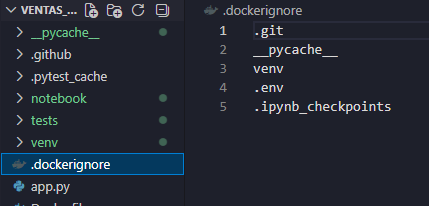

# Creación del Dockerfile

Se creó un `Dockerfile` siguiendo buenas prácticas de Docker, utilizando una imagen base ligera (`python:3.12-slim`) y aprovechando la caché mediante la copia previa del archivo `requirements.txt` antes del código fuente.

Dockerfile utilizado:

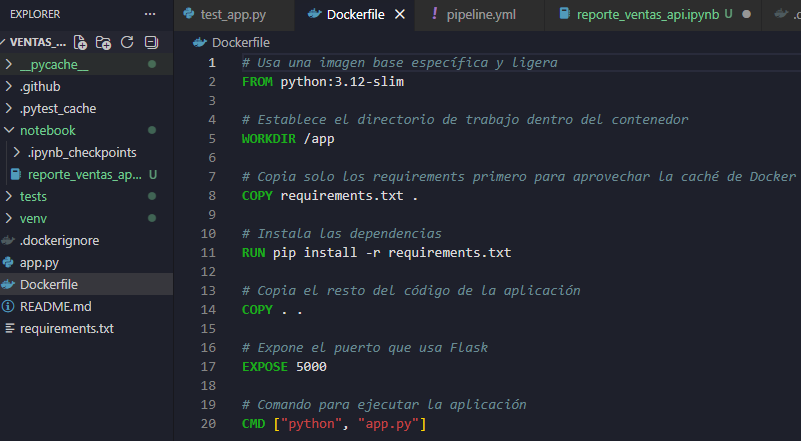

# Construcción de la Imagen Docker

Con el Dockerfile configurado, se construyó la imagen Docker utilizando una etiqueta con versión (`1.0.0`), evitando depender únicamente de la etiqueta `latest`.

Comando utilizado:

```bash
docker build -t ventas-api:1.0.0 .
```

Al finalizar el proceso, Docker generó correctamente la imagen de la aplicación.

**Evidencia**

- Terminal ejecutando el comando `docker build`.
- Resultado exitoso de la construcción de la imagen.

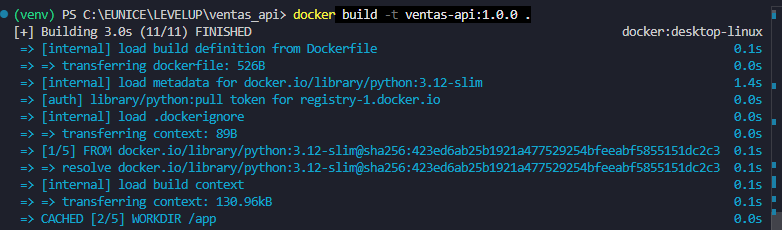

---


# Verificación de la Imagen

Después de construir la imagen, se verificó que esta estuviera disponible localmente mediante el listado de imágenes Docker.

Comando utilizado:

```bash
docker images
```

En el listado se confirmó la existencia de la imagen `ventas-api` con la versión `1.0.0`.

**Evidencia**

- Resultado del comando `docker images`, mostrando la imagen creada.

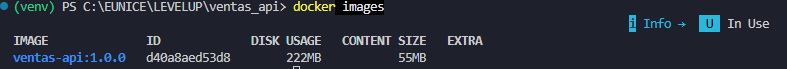

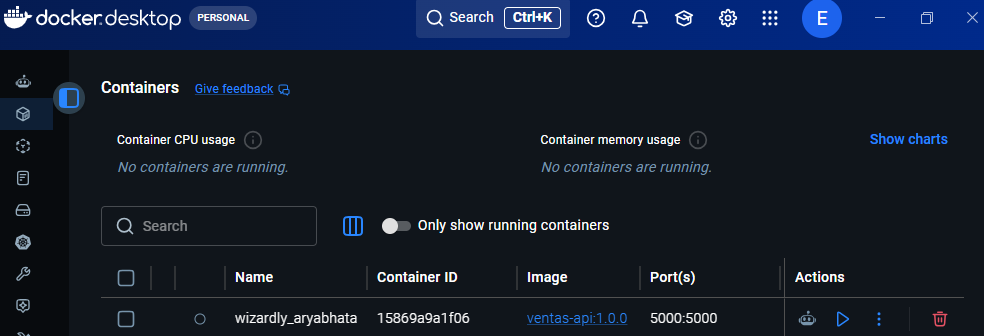

---

# Ejecución del Contenedor

Posteriormente se ejecutó la imagen para comprobar que la aplicación funcionara correctamente dentro de un contenedor Docker.

Comando utilizado:

```bash
docker run -p 5000:5000 ventas-api:1.0.0
```

El puerto 5000 del contenedor fue enlazado con el puerto 5000 del equipo local, permitiendo acceder a la API desde el navegador.

**Capturas de pantalla**

- Terminal ejecutando el comando `docker run`.

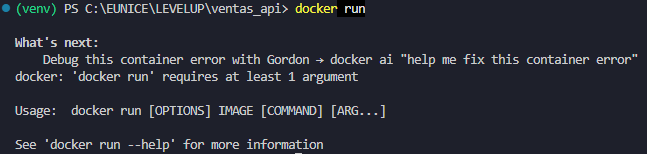

- Navegador mostrando la respuesta de la API en `http://localhost:5000`.

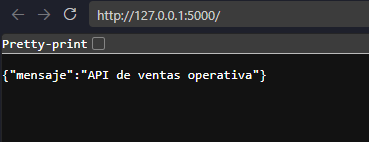

- (Opcional) Resultado del comando `docker ps`, evidenciando el contenedor en ejecución.

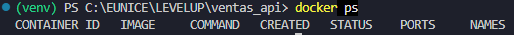

---

# Buenas Prácticas Aplicadas

Durante esta etapa se aplicaron diversas buenas prácticas para optimizar la creación y administración de la imagen Docker:

- Uso de una imagen base ligera (`python:3.12-slim`).
- Separación de la instalación de dependencias para aprovechar la caché de Docker.
- Exclusión de archivos innecesarios mediante `.dockerignore`.
- Versionado explícito de la imagen (`ventas-api:1.0.0`).
- Verificación del funcionamiento del contenedor antes de continuar con el pipeline CI/CD.

---

# Resultados

Como resultado de esta fase, la aplicación fue contenerizada exitosamente. Se obtuvo una imagen Docker optimizada y versionada, la cual fue ejecutada correctamente en un contenedor, verificando que la API respondiera de la misma manera que en el entorno local. Con ello, el proyecto quedó preparado para la siguiente etapa: la automatización del proceso mediante GitHub Actions y la implementación del pipeline CI/CD.

# Automatización del Pipeline CI/CD

En la etapa final del proyecto se implementó un pipeline de Integración Continua y Entrega Continua (CI/CD) utilizando GitHub Actions. Su objetivo es automatizar la validación, construcción y preparación del despliegue de la aplicación cada vez que se realiza un cambio en la rama principal del repositorio.

---

# Creación del Workflow

Se creó el archivo `pipeline.yml` dentro de la ruta `.github/workflows/`, donde se definió el flujo de automatización del proyecto. El pipeline está compuesto por tres etapas principales:

- **Test:** instala las dependencias y ejecuta las pruebas automatizadas.
- **Build:** construye y publica la imagen Docker únicamente si las pruebas fueron exitosas.
- **Deploy:** prepara el despliegue de la aplicación.

La ejecución secuencial se logró mediante la directiva `needs`, garantizando que cada etapa se ejecute únicamente si la anterior finaliza correctamente.

**Evidencia**

- carpeta `.github/workflows/` y el archivo `pipeline.yml`.

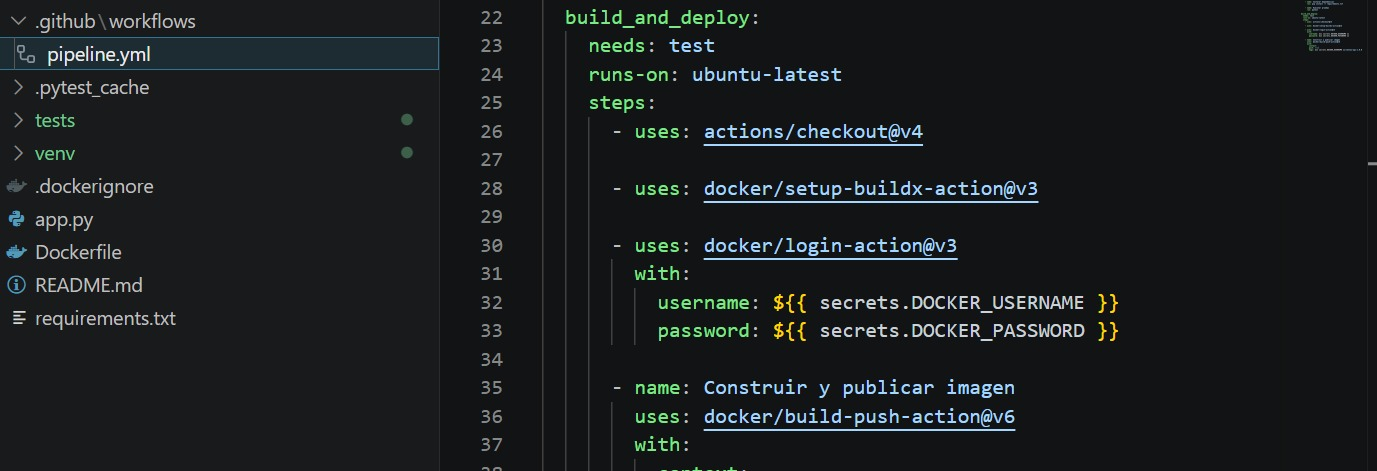

---

# Configuración del Pipeline

El workflow fue configurado para ejecutarse automáticamente cada vez que se realiza un `push` sobre la rama `main`.

Las principales actividades automatizadas fueron:

- Descarga del código fuente.
- Configuración del entorno de Python.
- Instalación de dependencias.
- Ejecución de pruebas con `pytest`.
- Construcción de la imagen Docker.
- Publicación de la imagen en Docker Hub.
- Preparación del despliegue.

De esta manera se garantiza que únicamente se publiquen versiones que hayan superado todas las validaciones.

---


# Gestión Segura de Credenciales

Como parte de las buenas prácticas de seguridad, las credenciales utilizadas para publicar la imagen en Docker Hub no fueron almacenadas dentro del código fuente.

Para ello se configuraron los siguientes **GitHub Secrets**:

- `DOCKER_USERNAME`
- `DOCKER_PASSWORD`

Estos secretos permiten autenticar el workflow sin exponer información sensible dentro del repositorio.

**Evidencia**

- Captura de la sección **Settings → Secrets and variables → Actions**, mostrando la existencia de los secretos configurados (sin revelar sus valores).

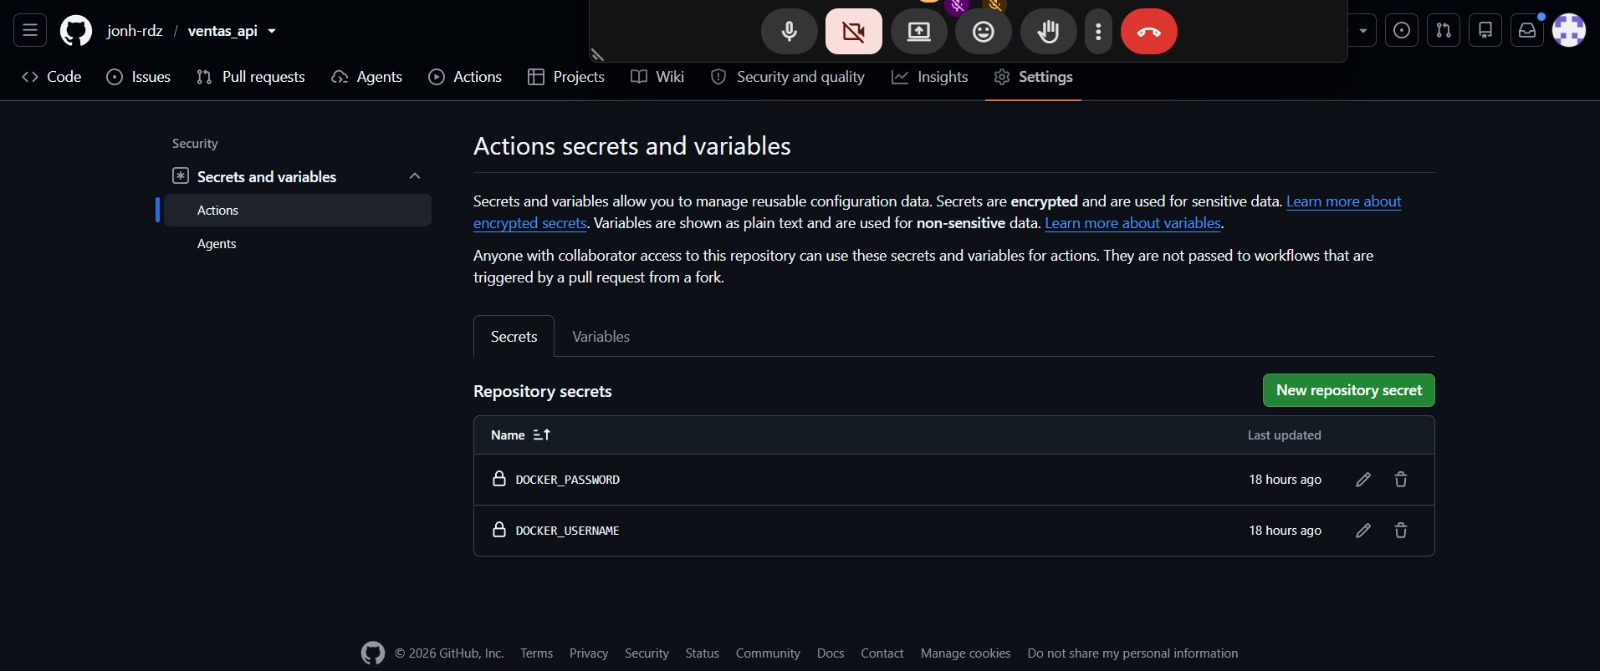

---

# Ejecución del Pipeline

Una vez creado el workflow, se registró mediante Git y se envió al repositorio remoto.

Comandos utilizados:

```bash
git add .github/workflows/pipeline.yml
git commit -m "Crea pipeline CI/CD con etapas de test, build y deploy"
git push origin main
```

Al realizar el `push`, GitHub Actions detectó automáticamente el cambio e inició la ejecución del pipeline.

---

# Validación del Pipeline

Después de ejecutarse el workflow, se verificó que todas las etapas finalizaran correctamente.

Las etapas ejecutadas fueron:

- Test
- Build
- Deploy

El éxito de estas tres fases confirmó que la aplicación fue validada, contenerizada y preparada para su despliegue sin intervención manual.

**Evidencia**

- Captura de la pestaña **Actions** del repositorio mostrando el pipeline ejecutado correctamente.
- Captura donde las etapas **Test**, **Build** y **Deploy** aparezcan en color verde.

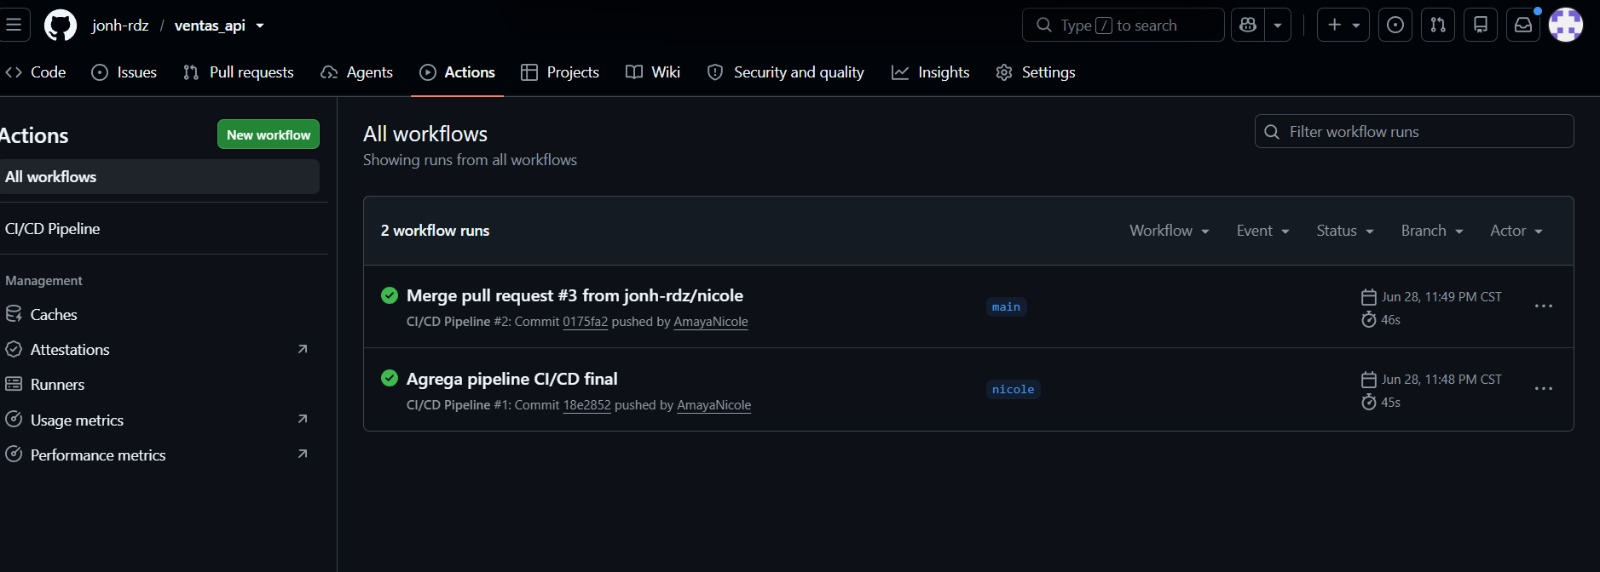

---

# Publicación de la Imagen

Como parte del proceso automatizado, la imagen Docker fue publicada correctamente en Docker Hub utilizando versionamiento explícito.

Se generaron las siguientes etiquetas:

- `1.0.0`
- `latest`

Esto facilita la administración de versiones y el despliegue de diferentes ediciones de la aplicación.

**Evidencia**

- Captura del repositorio en Docker Hub mostrando la imagen **ventas-api** y las etiquetas `1.0.0` y `latest`.

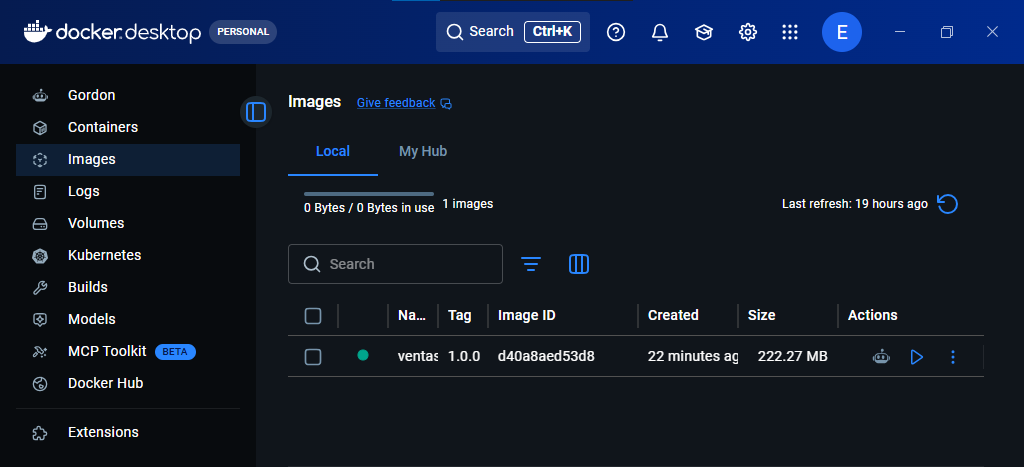

---

# Buenas Prácticas Aplicadas

Durante esta etapa se implementaron diversas buenas prácticas de DevOps:

- Automatización completa mediante GitHub Actions.
- Ejecución secuencial utilizando `needs`.
- Validación automática mediante pruebas antes del Build.
- Uso de GitHub Secrets para proteger credenciales.
- Versionamiento explícito de la imagen Docker.
- Automatización del proceso de integración y despliegue.

---

# Resultados

Como resultado final se obtuvo un pipeline CI/CD completamente funcional. Cada cambio realizado en la rama principal activa automáticamente la ejecución de pruebas, la construcción de la imagen Docker, su publicación en Docker Hub y la preparación del despliegue. Esto permitió automatizar el ciclo de integración continua, reducir errores manuales y asegurar que únicamente las versiones validadas sean distribuidas.

---

# Conclusión

La integración de Flask, Docker y GitHub Actions permitió implementar un flujo de trabajo similar al utilizado en entornos profesionales de desarrollo de software. La automatización del pipeline agiliza el proceso de integración, mejora la calidad del código mediante pruebas automáticas y facilita el despliegue de nuevas versiones de la aplicación, demostrando la importancia de aplicar prácticas de CI/CD en proyectos modernos.